# Lab 5: Ordinary Least Squares (OLS) & Gradient Descent for Linear Regression

**Course:** Machine Learning &nbsp;|&nbsp; **Lab:** 5
**Topic:** Implementation of OLS and Batch Gradient Descent for Simple Linear Regression

**Dataset:** Height (X, independent variable) vs Weight (y, dependent variable)

| Observation | Height (X) | Weight (y) |
|---|---|---|
| 1 | 0.5 | 1.4 |
| 2 | 2.3 | 1.9 |
| 3 | 2.9 | 3.2 |

**Objectives**
- Implement simple linear regression from scratch using two approaches:
  1. **Analytical:** OLS closed-form solution
  2. **Iterative:** Batch Gradient Descent
- Compare and verify the resulting parameters (m and c)
- Compute R², Standard Error, t-statistic and p-value for slope significance
- Visualize fitted regression lines and loss convergence


## Task 1: Environment Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# =====================================================================
# Dataset Definition
# =====================================================================
X = np.array([0.5, 2.3, 2.9])
y = np.array([1.4, 1.9, 3.2])

X, y

(array([0.5, 2.3, 2.9]), array([1.4, 1.9, 3.2]))

## Task 2: Implement OLS Function

In [2]:
def ols_linear_regression(X, y):
    """
    Compute linear regression parameters analytically using OLS
    closed-form formulas.

    Parameters:
        X (np.ndarray): Input feature vector (Height)
        y (np.ndarray): Target vector (Weight)

    Returns:
        m (float): Optimal slope
        c (float): Optimal intercept
    """
    # 1.1: Compute mean of X and mean of y
    x_mean = np.mean(X)
    y_mean = np.mean(y)

    # 1.2: Compute numerator and denominator for slope 'm'
    numerator = np.sum((X - x_mean) * (y - y_mean))
    denominator = np.sum((X - x_mean) ** 2)
    m = numerator / denominator

    # 1.3: Compute intercept 'c'
    c = y_mean - m * x_mean

    return m, c

## Task 3: Implement Batch Gradient Descent

In [3]:
def gradient_descent(X, y, alpha=0.05, epochs=1000):
    """
    Optimize linear regression parameters using batch gradient descent.

    Parameters:
        X (np.ndarray): Input feature vector
        y (np.ndarray): Target vector
        alpha (float): Learning rate
        epochs (int): Total training iterations

    Returns:
        m (float): Learned slope
        c (float): Learned intercept
        loss_history (list): MSE loss recorded per epoch
    """
    m = 0.0
    c = 0.0
    n = len(X)
    loss_history = []

    for epoch in range(epochs):
        # 2.1: Compute linear predictions (y_pred = m*X + c)
        y_pred = m * X + c

        # 2.2: Compute MSE loss and store in loss_history
        loss = np.mean((y_pred - y) ** 2)
        loss_history.append(loss)

        # 2.3: Compute partial derivatives dm and dc
        dm = (2 / n) * np.sum((y_pred - y) * X)
        dc = (2 / n) * np.sum(y_pred - y)

        # 2.4: Update parameters m and c using gradients and learning rate alpha
        m = m - alpha * dm
        c = c - alpha * dc

    return m, c, loss_history

## Task 4: Implement Statistical Evaluation Function (R² and p-value)

In [4]:
def compute_evaluation_metrics(X, y, y_pred, m):
    """
    Calculate R-squared and statistical significance (p-value) of the
    slope parameter.

    Parameters:
        X (np.ndarray): Input feature vector
        y (np.ndarray): Target ground truth vector
        y_pred (np.ndarray): Predicted values from model
        m (float): Slope parameter

    Returns:
        r2 (float): Coefficient of determination
        t_stat (float): Student's t-statistic for slope
        p_val (float): Two-tailed p-value
    """
    n = len(X)
    df = n - 2

    # 3.1: SS_res (residual sum of squares) and SS_tot (total sum of squares)
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)

    # 3.2: R-squared (R2)
    r2 = 1 - (ss_res / ss_tot)

    # 3.3: Standard Error of the slope SE(m)
    residual_variance = ss_res / df
    se_m = np.sqrt(residual_variance / np.sum((X - np.mean(X)) ** 2))

    # 3.4: t-statistic (t = m / se_m)
    t_stat = m / se_m

    # 3.5: Two-tailed p-value using the Student's t-distribution
    p_val = 2 * stats.t.sf(np.abs(t_stat), df)

    return r2, t_stat, p_val

## Task 5: Model Execution & Evaluation Comparison

In [5]:
# --- Execute OLS ---
m_ols, c_ols = ols_linear_regression(X, y)
y_pred_ols = m_ols * X + c_ols
r2_ols, t_ols, p_ols = compute_evaluation_metrics(X, y, y_pred_ols, m_ols)

print("=====================OLS RESULTS=====================")
print(f"Equation: y = {m_ols:.4f}x + {c_ols:.4f}")
print(f"R-squared: {r2_ols:.4f}")
print(f"t-statistic: {t_ols:.4f}")
print(f"p-value: {p_ols:.4f}\n")

# --- Execute Gradient Descent ---
alpha = 0.05
epochs = 1500
m_gd, c_gd, losses = gradient_descent(X, y, alpha=alpha, epochs=epochs)
y_pred_gd = m_gd * X + c_gd
r2_gd, t_gd, p_gd = compute_evaluation_metrics(X, y, y_pred_gd, m_gd)

print("===============GRADIENT DESCENT RESULTS===============")
print(f"Equation: y = {m_gd:.4f}x + {c_gd:.4f}")
print(f"R-squared: {r2_gd:.4f}")
print(f"t-statistic: {t_gd:.4f}")
print(f"p-value: {p_gd:.4f}")

=====================OLS RESULTS=====================
Equation: y = 0.6410x + 0.9487
R-squared: 0.7425
t-statistic: 1.6981
p-value: 0.3388

===============GRADIENT DESCENT RESULTS===============
Equation: y = 0.6410x + 0.9487
R-squared: 0.7425
t-statistic: 1.6981
p-value: 0.3388


## Task 6: Visualization

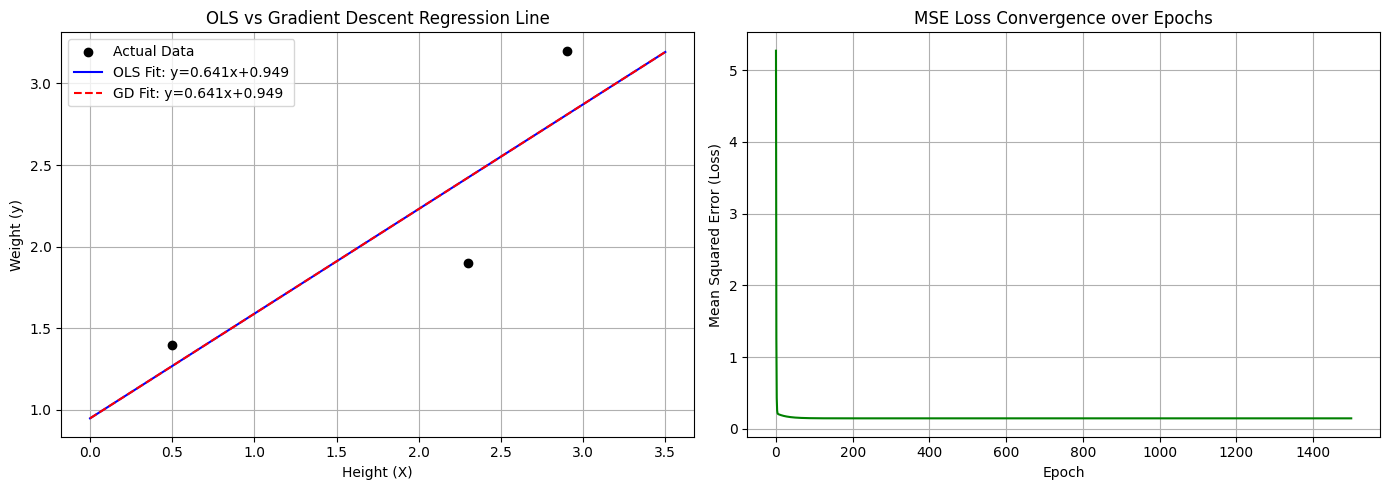

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Regression Fit Comparison
axes[0].scatter(X, y, color="black", label="Actual Data", zorder=5)

x_vals = np.linspace(0, 3.5, 100)
axes[0].plot(x_vals, m_ols * x_vals + c_ols, color="blue",
             label=f"OLS Fit: y={m_ols:.3f}x+{c_ols:.3f}")
axes[0].plot(x_vals, m_gd * x_vals + c_gd, color="red", linestyle="--",
             label=f"GD Fit: y={m_gd:.3f}x+{c_gd:.3f}")

axes[0].set_title("OLS vs Gradient Descent Regression Line")
axes[0].set_xlabel("Height (X)")
axes[0].set_ylabel("Weight (y)")
axes[0].legend()
axes[0].grid(True)

# Subplot 2: Loss Convergence Curve
axes[1].plot(range(epochs), losses, color="green")
axes[1].set_title("MSE Loss Convergence over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Mean Squared Error (Loss)")
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Lab Report & Viva Questions

1. **Analytical vs. Iterative Comparison:** Do the values of (m, c) and R² obtained via Gradient Descent match those from OLS? If there is a slight difference, why?
2. **Interpreting R² vs. p-value for Small Sample Sizes (n = 3):** The R² score is high (> 0.80 in general for such small n), indicating strong correlation, yet the p-value for the slope may exceed α = 0.05. Explain why a high R² can coexist with a non-significant p-value when df = 1.
3. **Hypothesis Testing:** State H₀ and H₁ tested by the t-statistic on the slope m.
4. **Learning Rate Sensitivity:** What happens to convergence if α = 1.0? What happens if α = 0.0001?
5. **Computational Scalability:** The closed-form OLS requires computing (XᵀX)⁻¹. Why is Gradient Descent preferred for high-dimensional datasets with millions of features/samples?

*(Answer each question in your own words in your final lab record, referencing the results/plots produced above.)*
